<a href="https://colab.research.google.com/github/IshworC/AI-and-ML/blob/main/worksheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6CS012 - AI and Machine Learning
# Ishwor Chalise (2408475)

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.metrics import classification_report

# Set random seeds for reproducibility
tf.random.set_seed(123)
np.random.seed(123)

###Define dataset paths

In [3]:
# Update these paths according to your environment
base_dir = "/content/drive/MyDrive/Colab Notebooks/FruitinAmazon"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

print("Train directory:", train_dir)
print("Test directory:", test_dir)
print("Classes:", os.listdir(train_dir))

Train directory: /content/drive/MyDrive/Colab Notebooks/FruitinAmazon/train
Test directory: /content/drive/MyDrive/Colab Notebooks/FruitinAmazon/test
Classes: ['tucuma', 'pupunha', 'graviola', 'guarana', 'acai', 'cupuacu']


###Visualize one image from each class

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


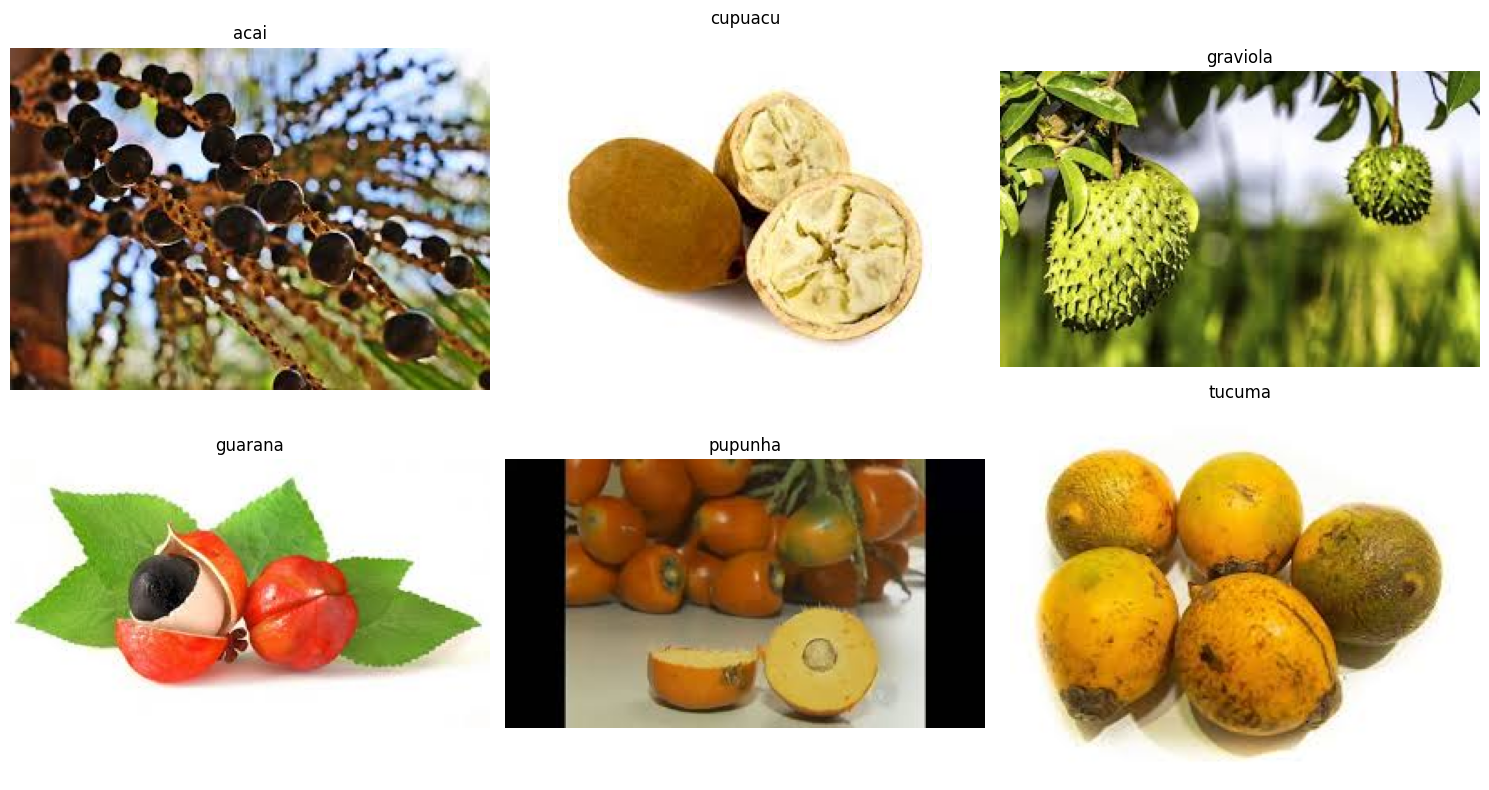

In [4]:
# Get class names from train folder
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes found:", class_names)

# Select one random image per class
sample_images = []
for cls in class_names:
    cls_path = os.path.join(train_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if images:
        img_name = np.random.choice(images)
        img_path = os.path.join(cls_path, img_name)
        sample_images.append((cls, img_path))

# Display images in a grid (2 rows)
num_classes = len(sample_images)
rows = 2
cols = (num_classes + 1) // 2   # ceiling division

fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
axes = axes.flatten()

for i, (cls, img_path) in enumerate(sample_images):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=12)
    axes[i].axis('off')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

###Check for corrupted images and remove them

In [7]:
def remove_corrupted_images(directory):
    corrupted_paths = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)
                try:
                    with Image.open(file_path) as img:
                        img.verify()   # verify integrity
                except (IOError, SyntaxError) as e:
                    corrupted_paths.append(file_path)
                    os.remove(file_path)
                    print(f"Removed corrupted image: {file_path}")
    if not corrupted_paths:
        print("No corrupted images found.")
    return corrupted_paths

# Check both train and test directories
print("Checking train directory...")
corrupted_train = remove_corrupted_images(train_dir)
print("\nChecking test directory...")
corrupted_test = remove_corrupted_images(test_dir)

Checking train directory...
No corrupted images found.

Checking test directory...
No corrupted images found.


###Load and preprocess image data using

In [9]:
img_height, img_width = 128, 128
batch_size = 16
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Test dataset (do NOT map yet if you need class_names)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False
)

# Get class names BEFORE mapping
class_names = test_ds.class_names
num_classes = len(class_names)
print("Number of classes:", num_classes)
print("Class names:", class_names)

# apply normalization to all datasets
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Number of classes: 6
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


###Build the CNN model according to the specified architecture

In [10]:
model = keras.Sequential([
    # Convolutional block 1
    layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', strides=1, activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Convolutional block 2
    layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', strides=1, activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Flatten and fully connected layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

###Compile the model

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

###Train the model with callbacks

In [12]:
# Callbacks
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

early_stop_cb = tf.keras.callbacks.EarlyStopping(
    patience=15,
    restore_best_weights=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,          # early stopping will stop earlier if needed
    batch_size=batch_size,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=1
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.1556 - loss: 2.0607
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 248ms/step - accuracy: 0.1528 - loss: 2.0549 - val_accuracy: 0.0000e+00 - val_loss: 1.8385
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.2382 - loss: 1.6492
Epoch 2: val_accuracy improved from 0.00000 to 0.33333, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step - accuracy: 0.2639 - loss: 1.6234 - val_accuracy: 0.3333 - val_loss: 1.6275
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.3882 - loss: 1.4871
Epoch 3: val_accuracy did not improve from 0.33333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 353ms/step - accuracy: 0.4722 - loss: 1.3989 - val_accuracy: 0.2778 - val_loss: 1.6297
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.7372 - loss: 1.0656
Epoch 4: val_accuracy improved from 0.33333 to 0.83333, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - accuracy: 0.7222 - loss: 1.0084 - val_accuracy: 0.8333 - val_loss: 0.8344
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.6844 - loss: 0.8428
Epoch 5: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - accuracy: 0.7083 - loss: 0.8033 - val_accuracy: 0.2778 - val_loss: 1.7373
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7552 - loss: 0.6515
Epoch 6: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - accuracy: 0.7917 - loss: 0.6206 - val_accuracy: 0.8333 - val_loss: 0.5694
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7997 - loss: 0.5007
Epoch 7: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - accuracy: 0.8056 - loss: 0.4739 - val_accuracy: 0.8333 - val_loss: 0.8082
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9521 - loss: 0.259


Epoch 9: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - accuracy: 0.9583 - loss: 0.1393 - val_accuracy: 0.8889 - val_loss: 0.5426
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 1.0000 - loss: 0.0940
Epoch 10: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - accuracy: 1.0000 - loss: 0.0702 - val_accuracy: 0.7778 - val_loss: 0.8397
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 1.0000 - loss: 0.0585
Epoch 11: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - accuracy: 1.0000 - loss: 0.0540 - val_accuracy: 0.8889 - val_loss: 0.4153
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.9941 - loss: 0.0363
Epoch 12: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 332ms/step - accuracy: 0.9861 - loss: 0.0579 - val_accuracy: 0.8889 - val_loss: 0.2582
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.9972 - loss

###Visualisation: Training and validation loss / accuracy

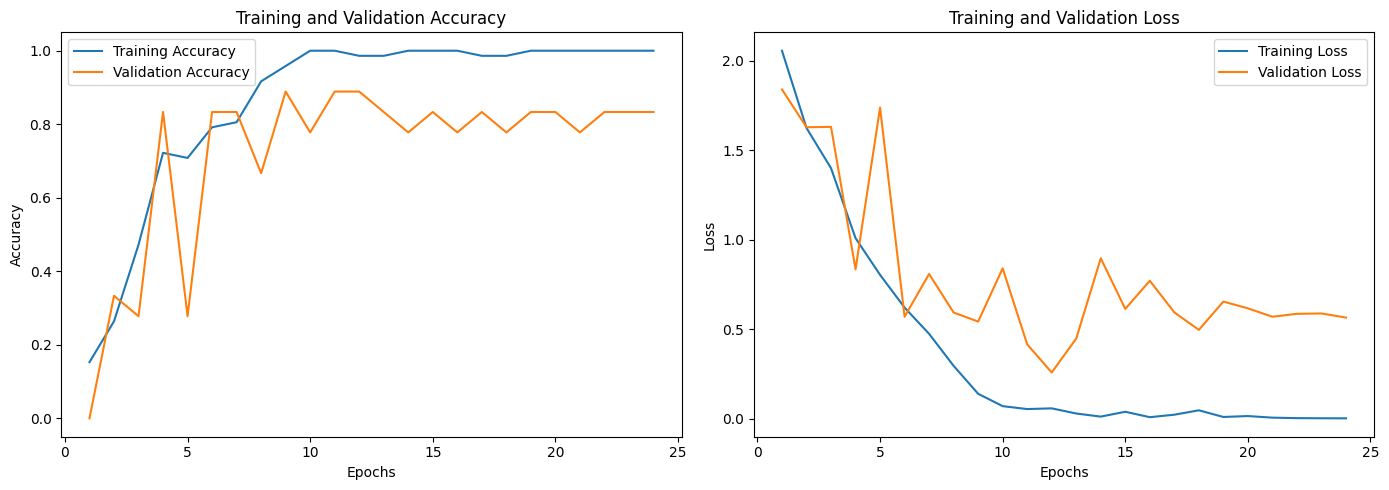

In [13]:
# Plot training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

###Evaluate the model on the test set

In [14]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5333 - loss: 1.3723
Test accuracy: 0.5333
Test loss: 1.3723


###Save and load the model (.h5 format)

In [15]:
# Save the trained model
model.save('fruit_cnn_model.h5')
print("Model saved as 'fruit_cnn_model.h5'")

# Load the saved model
loaded_model = keras.models.load_model('fruit_cnn_model.h5')

# Re-evaluate loaded model to verify
loaded_test_loss, loaded_test_acc = loaded_model.evaluate(test_ds)
print(f"Loaded model - Test accuracy: {loaded_test_acc:.4f}")

Model saved as 'fruit_cnn_model.h5'
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.5333 - loss: 1.3723
Loaded model - Test accuracy: 0.5333


###Predictions and classification report

In [18]:
from sklearn.metrics import classification_report

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Classification report without warnings
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

        acai       0.56      1.00      0.71         5
     cupuacu       1.00      0.20      0.33         5
    graviola       0.44      0.80      0.57         5
     guarana       0.80      0.80      0.80         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.33      0.40      0.36         5

    accuracy                           0.53        30
   macro avg       0.52      0.53      0.46        30
weighted avg       0.52      0.53      0.46        30

